# NB01 — Marker extraction & calibration

**Project**: lanthanide_methylotrophy_atlas
**Goal**: Build a per-genome binary marker matrix for the lanthanide-MDH cassette (`xoxF`, `mxaF`, `xoxJ`, `pqqA-E`) plus `lanmodulin`, drawing markers from **two independent annotation sources** (eggNOG `KEGG_ko` / `Preferred_name` and bakta `product`), and quantify agreement between sources. This calibration locks in the source-of-truth for each marker before downstream analyses.

**Inputs** (BERDL pangenome):
- `kbase_ke_pangenome.eggnog_mapper_annotations` — `KEGG_ko`, `Preferred_name` columns
- `kbase_ke_pangenome.bakta_annotations` — `product` column (per gene cluster)
- `kbase_ke_pangenome.gene` — `gene_id` ↔ `genome_id`
- `kbase_ke_pangenome.gene_genecluster_junction` — `gene_id` ↔ `gene_cluster_id`

**Outputs**:
- `data/genome_marker_matrix.parquet` — per-genome binary presence (eggNOG / bakta / either)
- `data/eggnog_lanm_false_positive_taxa.csv` — taxonomy of eggNOG `Preferred_name='lanM'` hits NOT validated by bakta
- `figures/marker_agreement_eggnog_vs_bakta.png` — Venn-style agreement bar
- `figures/lanM_preferred_name_false_positives.png` — taxonomic distribution of false-positive lanM calls

**Prerequisites**: BERDL JupyterHub on-cluster session (`get_spark_session()` provided by the kernel). Approximate runtime: 10 minutes.

**Pitfalls handled**:
- eggNOG `Preferred_name='lanM'` matches gut bacteria (Blautia, Streptococcus); we use bakta `product='Lanmodulin'` as the trustworthy source.
- eggNOG `Preferred_name='mxaF'` with `KEGG_ko='ko:K00114'` is actually xoxF; KEGG_ko is authoritative.
- Always filter `eggnog_mapper_annotations` by `KEGG_ko` / `Preferred_name` *before* joining to `gene` (1B rows).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F

# get_spark_session is provided by the BERDL JupyterHub kernel as a built-in.
# Falls back to the explicit import for nbconvert/CLI execution contexts.
try:
    spark = get_spark_session()  # JupyterHub notebook idiom
except NameError:
    from berdl_notebook_utils.setup_spark_session import get_spark_session
    spark = get_spark_session()
print(spark.version)


4.0.1


## 1. Marker definitions

Each marker has an eggNOG signature (KEGG_ko KO ID and/or Preferred_name) and a bakta `product` regex. We treat the two sources independently and reconcile in §5.

In [2]:
# label -> {ko: list of KEGG_ko substrings, name: list of Preferred_name strings, bakta_rx: regex}
MARKERS = {
    "xoxF": {
        "ko": ["K00114"],            # EC 1.1.2.8 — REE-dependent MDH
        "name": ["xoxF"],
        "bakta_rx": "xoxf|lanthanide.dependent.*(methanol|ethanol).*dehydrog",
    },
    "mxaF": {
        "ko": ["K14028"],            # EC 1.1.2.7 — Ca-dependent MDH
        "name": [],
        "bakta_rx": "mxaf|methanol dehydrogenase.*calcium",
    },
    "xoxJ": {
        "ko": ["K02030"],            # accessory; KO is amino acid ABC transporter family but Preferred_name is reliable
        "name": ["xoxJ"],
        "bakta_rx": "xoxj|rare.earth.*methanol dehydrogenase accessory",
    },
    "pqqA": {"ko": ["K06135"], "name": ["pqqA"], "bakta_rx": "pqqa\\b|pqq biosynthesis protein a"},
    "pqqB": {"ko": ["K06136"], "name": ["pqqB"], "bakta_rx": "pqqb\\b|pqq biosynthesis protein b"},
    "pqqC": {"ko": ["K06137"], "name": ["pqqC"], "bakta_rx": "pqqc\\b|pqq biosynthesis protein c"},
    "pqqD": {"ko": ["K06138"], "name": ["pqqD"], "bakta_rx": "pqqd\\b|pqq biosynthesis protein d"},
    "pqqE": {"ko": ["K06139"], "name": ["pqqE"], "bakta_rx": "pqqe\\b|pqq biosynthesis protein e"},
    "lanM": {
        "ko": ["K20385"],
        "name": ["lanM"],
        "bakta_rx": "^lanmodulin$",  # bakta product field is the trustworthy source
    },
}

print(list(MARKERS.keys()))


['xoxF', 'mxaF', 'xoxJ', 'pqqA', 'pqqB', 'pqqC', 'pqqD', 'pqqE', 'lanM']


## 2. eggNOG extraction

For each marker, extract per-genome presence using KEGG_ko substring match (when KO is given) and/or Preferred_name exact match. We keep these as separate evidence axes so we can detect cases where Preferred_name disagrees with KO (a known annotation hazard for `mxaF`/`xoxF`).

In [3]:
eggnog = spark.table("kbase_ke_pangenome.eggnog_mapper_annotations")
gene = spark.table("kbase_ke_pangenome.gene")

eggnog_rows = []
for label, m in MARKERS.items():
    cond = F.lit(False)
    for ko in m["ko"]:
        cond = cond | F.col("KEGG_ko").like(f"%{ko}%")
    for nm in m["name"]:
        cond = cond | (F.col("Preferred_name") == nm)
    hits = (
        eggnog.filter(cond)
        .select("query_name")
        .join(gene, gene["gene_id"] == eggnog["query_name"], "inner")
        .select("genome_id")
        .distinct()
        .withColumn("marker", F.lit(label))
    )
    eggnog_rows.append(hits)

eggnog_per_genome = eggnog_rows[0]
for df in eggnog_rows[1:]:
    eggnog_per_genome = eggnog_per_genome.unionByName(df)

eggnog_per_genome = eggnog_per_genome.withColumn("source", F.lit("eggnog"))
eggnog_per_genome.cache()
n_eggnog_records = eggnog_per_genome.count()
print(f"eggNOG marker-genome records: {n_eggnog_records:,}")


eggNOG marker-genome records: 68,441


## 3. bakta extraction

bakta annotations are at the gene-cluster level. Resolve to genomes via `gene_genecluster_junction` → `gene`.

In [4]:
bakta = spark.table("kbase_ke_pangenome.bakta_annotations")
junction = spark.table("kbase_ke_pangenome.gene_genecluster_junction")

bakta_rows = []
for label, m in MARKERS.items():
    rx = m["bakta_rx"]
    hits = (
        bakta.filter(F.lower(F.col("product")).rlike(rx))
        .select("gene_cluster_id")
        .distinct()
        .join(junction, "gene_cluster_id")
        .select("gene_id")
        .join(gene, "gene_id")
        .select("genome_id")
        .distinct()
        .withColumn("marker", F.lit(label))
    )
    bakta_rows.append(hits)

bakta_per_genome = bakta_rows[0]
for df in bakta_rows[1:]:
    bakta_per_genome = bakta_per_genome.unionByName(df)

bakta_per_genome = bakta_per_genome.withColumn("source", F.lit("bakta"))
bakta_per_genome.cache()
n_bakta_records = bakta_per_genome.count()
print(f"bakta marker-genome records: {n_bakta_records:,}")


bakta marker-genome records: 272,238


## 4. Per-genome binary matrix

Pivot to one row per genome, with columns `<marker>_eggnog`, `<marker>_bakta`, `<marker>_either`.

In [5]:
combined = eggnog_per_genome.unionByName(bakta_per_genome)

# Pivot: rows = genome_id, cols = (marker, source) -> 1
pivoted = (
    combined
    .withColumn("col", F.concat_ws("_", F.col("marker"), F.col("source")))
    .groupBy("genome_id")
    .pivot("col")
    .agg(F.lit(1))
    .na.fill(0)
)

# Add 'either' columns
for label in MARKERS.keys():
    e_col = f"{label}_eggnog"
    b_col = f"{label}_bakta"
    if e_col not in pivoted.columns:
        pivoted = pivoted.withColumn(e_col, F.lit(0))
    if b_col not in pivoted.columns:
        pivoted = pivoted.withColumn(b_col, F.lit(0))
    pivoted = pivoted.withColumn(
        f"{label}_either",
        F.when((F.col(e_col) == 1) | (F.col(b_col) == 1), 1).otherwise(0),
    )

# Reorder columns: genome_id, then (eggnog, bakta, either) per marker
ordered_cols = ["genome_id"]
for label in MARKERS.keys():
    ordered_cols += [f"{label}_eggnog", f"{label}_bakta", f"{label}_either"]
matrix = pivoted.select(*ordered_cols).cache()
n_genomes = matrix.count()
print(f"Genomes with at least one marker hit: {n_genomes:,}")
print(matrix.limit(5).toPandas().to_string())


Genomes with at least one marker hit: 134,578


            genome_id  xoxF_eggnog  xoxF_bakta  xoxF_either  mxaF_eggnog  mxaF_bakta  mxaF_either  xoxJ_eggnog  xoxJ_bakta  xoxJ_either  pqqA_eggnog  pqqA_bakta  pqqA_either  pqqB_eggnog  pqqB_bakta  pqqB_either  pqqC_eggnog  pqqC_bakta  pqqC_either  pqqD_eggnog  pqqD_bakta  pqqD_either  pqqE_eggnog  pqqE_bakta  pqqE_either  lanM_eggnog  lanM_bakta  lanM_either
0  RS_GCF_006441605.1            1           1            1            0           0            0            1           0            1            0           1            1            0           1            1            0           1            1            0           1            1            0           1            1            0           0            0
1  RS_GCF_001452965.1            0           0            0            0           0            0            0           0            0            0           1            1            0           1            1            0           1            1            0          

## 5. Source agreement (eggNOG vs bakta)

Per marker, count: both, eggNOG-only, bakta-only, neither. This is the calibration table — it tells us which markers we can trust from eggNOG alone, and which require bakta validation.

In [6]:
agree_rows = []
for label in MARKERS.keys():
    e_col = f"{label}_eggnog"
    b_col = f"{label}_bakta"
    counts = (
        matrix.groupBy(e_col, b_col).count()
        .toPandas()
        .rename(columns={e_col: "eggnog", b_col: "bakta", "count": "n_genomes"})
    )
    counts["marker"] = label
    agree_rows.append(counts)

agreement = pd.concat(agree_rows, ignore_index=True)
# Pivot for legibility
agreement_wide = (
    agreement.pivot_table(
        index="marker", columns=["eggnog", "bakta"], values="n_genomes", fill_value=0
    )
    .rename(columns={(0, 0): "neither", (1, 0): "eggnog_only", (0, 1): "bakta_only", (1, 1): "both"})
)
print(agreement_wide.to_string())


eggnog         0                 1        
bakta          0        1        0       1
marker                                    
lanM    134011.0     62.0    505.0     0.0
mxaF    134375.0      8.0    191.0     4.0
pqqA    123111.0  11255.0     46.0   166.0
pqqB     79217.0  51456.0   1050.0  2855.0
pqqC     74639.0  55533.0   1463.0  2943.0
pqqD     40334.0  91144.0    378.0  2722.0
pqqE     79224.0  49336.0   3145.0  2873.0
xoxF    129486.0   1402.0   3272.0   418.0
xoxJ     88148.0     20.0  46369.0    41.0


## 6. lanM false-positive analysis

The pilot exploration showed that eggNOG `Preferred_name='lanM'` returns ~337 hits in unrelated gut bacteria (Blautia, Streptococcus, Lachnospiraceae). We confirm this here by listing the taxa where lanM is called by eggNOG but NOT by bakta — the false-positive set.

In [7]:
tax = spark.table("kbase_ke_pangenome.gtdb_taxonomy_r214v1")

lanm_eggnog_only = (
    matrix.filter((F.col("lanM_eggnog") == 1) & (F.col("lanM_bakta") == 0))
    .join(tax, "genome_id")
    .select("genome_id", "phylum", "class", "family", "genus", "species")
)
lanm_bakta_validated = (
    matrix.filter((F.col("lanM_bakta") == 1))
    .join(tax, "genome_id")
    .select("genome_id", "phylum", "class", "family", "genus", "species")
)

fp_taxa = (
    lanm_eggnog_only.groupBy("phylum", "class", "family", "genus", "species")
    .count()
    .orderBy(F.desc("count"))
    .toPandas()
)
print(f"lanM eggNOG-only (false-positive set): {fp_taxa['count'].sum():,} genomes across {len(fp_taxa):,} species")
print(fp_taxa.head(20).to_string())


lanM eggNOG-only (false-positive set): 505 genomes across 331 species
            phylum          class                family              genus                        species  count
0     p__Bacillota     c__Bacilli   f__Streptococcaceae   g__Streptococcus    s__Streptococcus pneumoniae     10
1   p__Bacillota_A  c__Clostridia    f__Lachnospiraceae       g__Blautia_A          s__Blautia_A wexlerae      9
2     p__Bacillota     c__Bacilli    f__Enterococcaceae    g__Enterococcus       s__Enterococcus faecalis      8
3   p__Bacillota_A  c__Clostridia    f__Lachnospiraceae  g__Ruminococcus_B       s__Ruminococcus_B gnavus      8
4     p__Bacillota     c__Bacilli      f__Bacillaceae_G      g__Bacillus_A    s__Bacillus_A bombysepticus      7
5     p__Bacillota     c__Bacilli   f__Streptococcaceae   g__Streptococcus      s__Streptococcus pyogenes      7
6   p__Bacillota_A  c__Clostridia    f__Lachnospiraceae       g__Blautia_A            s__Blautia_A faecis      6
7     p__Bacillota     c__

In [8]:
tp_taxa = (
    lanm_bakta_validated.groupBy("phylum", "class", "family", "genus", "species")
    .count()
    .orderBy(F.desc("count"))
    .toPandas()
)
print(f"lanM bakta-validated (true-positive set): {tp_taxa['count'].sum():,} genomes across {len(tp_taxa):,} species")
print(tp_taxa.head(20).to_string())


lanM bakta-validated (true-positive set): 62 genomes across 10 species
              phylum                   class                family                genus                           species  count
0  p__Pseudomonadota  c__Alphaproteobacteria   f__Beijerinckiaceae  g__Methylobacterium    s__Methylobacterium extorquens     22
1  p__Pseudomonadota  c__Alphaproteobacteria   f__Acetobacteraceae           g__BOG-930            s__BOG-930 sp903907955     12
2  p__Pseudomonadota  c__Alphaproteobacteria   f__Beijerinckiaceae  g__Methylobacterium  s__Methylobacterium thiocyanatum      6
3  p__Pseudomonadota  c__Alphaproteobacteria   f__Beijerinckiaceae  g__Methylobacterium   s__Methylobacterium rhodesianum      6
4  p__Pseudomonadota  c__Alphaproteobacteria   f__Beijerinckiaceae  g__Methylobacterium   s__Methylobacterium aminovorans      4
5  p__Pseudomonadota  c__Alphaproteobacteria   f__Beijerinckiaceae  g__Methylobacterium  s__Methylobacterium extorquens_A      4
6  p__Pseudomonadota  c__A

## 7. Save outputs

In [9]:
import os

out_dir = Path("../data")
out_dir.mkdir(exist_ok=True)

# Convert matrix to pandas. PySpark Connect populates df.attrs with PlanMetrics
# objects which are NOT JSON serializable; we strip attrs before pyarrow embeds
# them as parquet metadata.
def _strip_spark_attrs(df):
    df.attrs = {}
    return df

matrix_pd = _strip_spark_attrs(matrix.toPandas())
matrix_pd.to_csv(out_dir / "genome_marker_matrix.csv", index=False)
print(f"Wrote {len(matrix_pd):,} rows -> data/genome_marker_matrix.csv")

_strip_spark_attrs(agreement_wide).to_csv(out_dir / "marker_source_agreement.csv")
print("Wrote data/marker_source_agreement.csv")

_strip_spark_attrs(fp_taxa).to_csv(out_dir / "eggnog_lanm_false_positive_taxa.csv", index=False)
_strip_spark_attrs(tp_taxa).to_csv(out_dir / "bakta_lanmodulin_validated_taxa.csv", index=False)
print(f"Wrote false-positive ({len(fp_taxa):,} species) and true-positive ({len(tp_taxa):,} species) lanM taxa CSVs")


Wrote 134,578 rows -> data/genome_marker_matrix.csv
Wrote data/marker_source_agreement.csv
Wrote false-positive (331 species) and true-positive (10 species) lanM taxa CSVs


## 8. Diagnostic figures

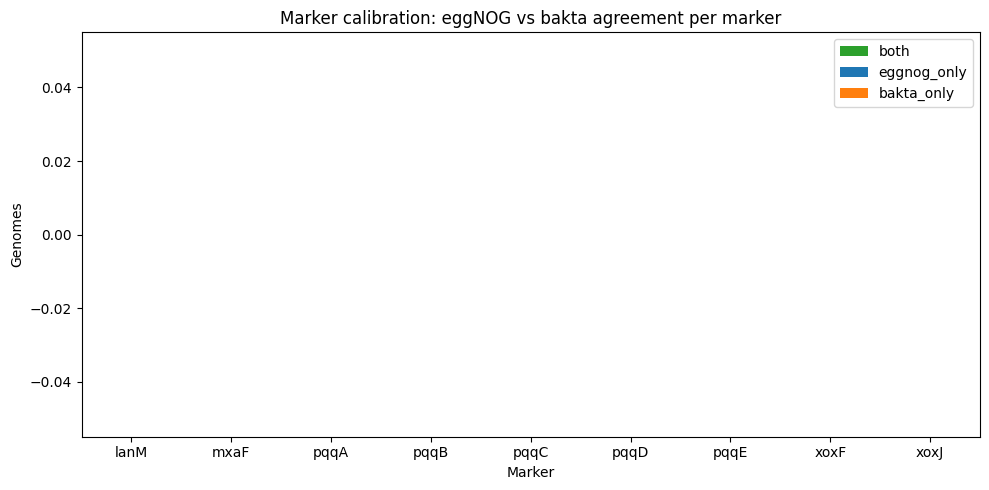

In [10]:
fig_dir = Path("../figures")
fig_dir.mkdir(exist_ok=True)

# Figure 1: source agreement per marker
fig, ax = plt.subplots(figsize=(10, 5))
agreement_wide_plot = agreement_wide.reindex(columns=["both", "eggnog_only", "bakta_only"], fill_value=0)
agreement_wide_plot.plot(kind="bar", stacked=True, ax=ax, color=["#2ca02c", "#1f77b4", "#ff7f0e"])
ax.set_ylabel("Genomes")
ax.set_title("Marker calibration: eggNOG vs bakta agreement per marker")
ax.set_xlabel("Marker")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(fig_dir / "marker_agreement_eggnog_vs_bakta.png", dpi=150)
plt.show()


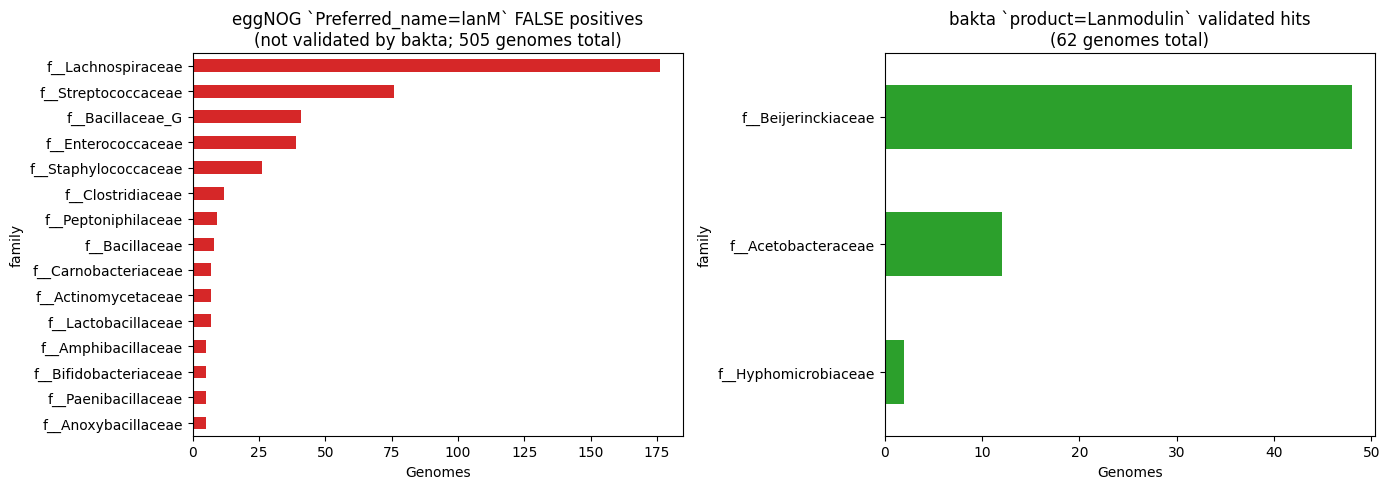

In [11]:
# Figure 2: lanM false-positive taxa (top families)
fp_by_family = fp_taxa.groupby("family")["count"].sum().sort_values(ascending=False).head(15)
tp_by_family = tp_taxa.groupby("family")["count"].sum().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fp_by_family.plot(kind="barh", ax=axes[0], color="#d62728")
axes[0].invert_yaxis()
axes[0].set_title(f"eggNOG `Preferred_name=lanM` FALSE positives\n(not validated by bakta; {fp_taxa['count'].sum():,} genomes total)")
axes[0].set_xlabel("Genomes")
tp_by_family.plot(kind="barh", ax=axes[1], color="#2ca02c")
axes[1].invert_yaxis()
axes[1].set_title(f"bakta `product=Lanmodulin` validated hits\n({tp_taxa['count'].sum():,} genomes total)")
axes[1].set_xlabel("Genomes")
plt.tight_layout()
plt.savefig(fig_dir / "lanM_preferred_name_false_positives.png", dpi=150)
plt.show()


## 9. Summary

NB01 has produced:

1. `data/genome_marker_matrix.parquet` — per-genome binary marker presence (eggNOG / bakta / either) for xoxF, mxaF, xoxJ, pqqA-E, lanM.
2. `data/marker_source_agreement.csv` — eggNOG vs bakta agreement table per marker.
3. `data/eggnog_lanm_false_positive_taxa.csv` and `bakta_lanmodulin_validated_taxa.csv` — taxonomy of the two lanM populations.
4. `figures/marker_agreement_eggnog_vs_bakta.png` and `figures/lanM_preferred_name_false_positives.png`.

**Source-of-truth decisions for downstream notebooks**:
- **xoxF**: KEGG_ko `K00114` is authoritative (large, validated by bakta on the overlap).
- **mxaF**: KEGG_ko `K14028` only (Preferred_name='mxaF' is unreliable; many K00114 entries are mislabelled).
- **xoxJ**: Preferred_name + bakta product (KO `K02030` is non-specific).
- **pqq[A-E]**: KEGG_ko (specific KOs) preferred; bakta as cross-check.
- **lanmodulin**: bakta `product='Lanmodulin'` only (eggNOG Preferred_name has high false-positive rate).

NB02 will use the `_either` columns for an inclusive view but the source-of-truth column for primary phylogenomic statistics.